<a href="https://colab.research.google.com/github/Vinutha-Reddy/Internship-Projects/blob/main/Project_05_CNN_Potato_Diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Project Title - Potato Leaf Disease Detection using Image Classification**

# **2. Problem Statement**
This project focuses on building an image classification model to detect and classify potato plant
diseases. The dataset consists of high-resolution images of potato leaves categorized into three
classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep
learning model that can accurately identify plant diseases and support agricultural diagnostics.

# **3. Project Objectives**

- Understand image classification using deep learning
- Perform data preprocessing and augmentation
- Train and evaluate a CNN-based model

# **4. Data Understanding**

**a. Load Dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data


**b. Checking the main folder**

In [ ]:
import os
print(os.listdir(path))

['PlantVillage', 'PotatoPlants']


**c. Print all sub directories**

In [ ]:
base_path = os.path.join(path,'PotatoPlants')
print(os.listdir(base_path))

['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


**d. Display 5 images of each class**

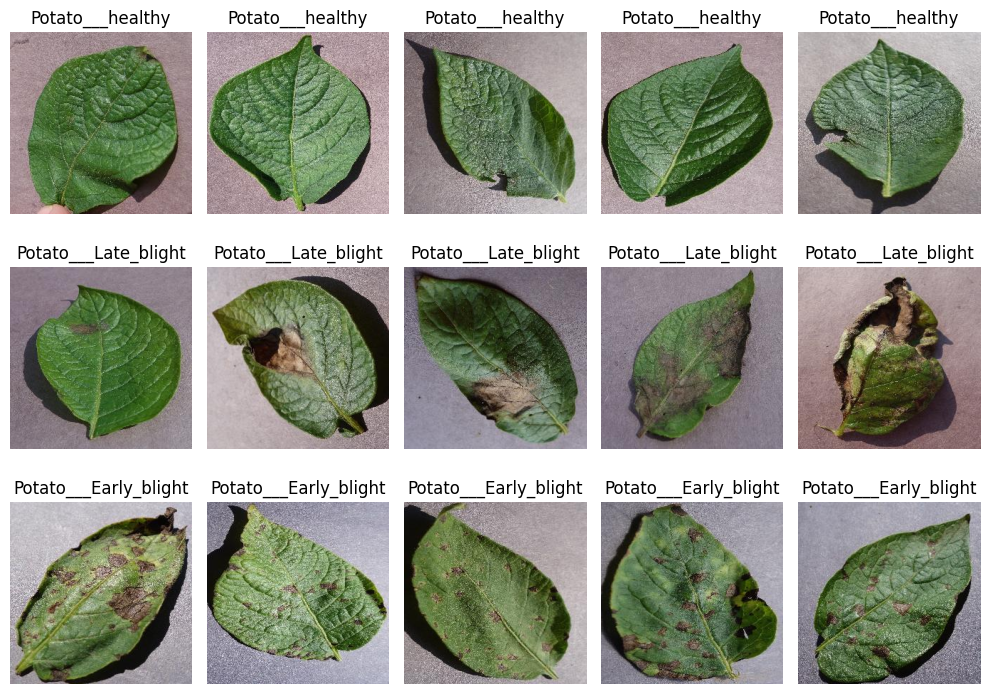

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

base_path = os.path.join(path,'PotatoPlants')
plt.figure(figsize=(10,12))

i = 1
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    images = os.listdir(class_path)[:5]
    for img in images:
      image_path = os.path.join(class_path,img)
      img = Image.open(image_path)

      plt.subplot(5,5,i)
      plt.imshow(img)
      plt.title(class_name)
      plt.axis('off')
      i+=1
plt.tight_layout()
plt.show()

In [ ]:
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    count = len(os.listdir(class_path))
    print(class_name,':',count)

Potato___healthy : 152
Potato___Late_blight : 1000
Potato___Early_blight : 1000


**e. Create dataframe which includes imagepath and labels**

In [ ]:
import pandas as pd
data=[]
base_path = os.path.join(path,'PotatoPlants')
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    for img in os.listdir(class_path):
      img_path = os.path.join(class_path,img)
      data.append([img_path,class_name])
df = pd.DataFrame(data,columns=['image_path','label'])

In [ ]:
df

,image_path,label
0,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
1,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
2,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
3,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
4,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___healthy
...,...,...
2147,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
2148,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
2149,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
2150,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight


**f. Shuffle data**

In [ ]:
df = df.sample(frac=1,random_state=42).reset_index()

In [ ]:
df

,index,image_path,label
0,1505,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
1,1660,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
2,889,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
3,306,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
4,1771,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
...,...,...,...
2147,1638,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
2148,1095,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
2149,1130,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
2150,1294,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight


**g. Find size of image**

In [ ]:
img = df['image_path'][0]
image = Image.open(img)
height,width = image.size
print(height,width)

256 256


# **5. Data preprocessing**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**a. Resize images**

In [ ]:
batch_size = 32
img_height = 224
img_width = 224

**b. Normalization and Data Augmentation**

In [ ]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **6. Split data for training,validation and testing**

In [ ]:
train_size = int(0.7* len(df))
test_size = int(0.15* len(df))
val_size = int(0.15* len(df))
print("train_size---->",train_size)
print("test_size---->",test_size)
print("val_size---->",val_size)

train_size----> 1506
test_size----> 322
val_size----> 322


In [ ]:
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:train_size+test_size]
val_data = df.iloc[train_size+test_size :]
print("train_data--->",len(train_data))
print("test_data--->",len(test_data))
print("val_data--->",len(val_data))

train_data---> 1506
test_data---> 322
val_data---> 324


In [ ]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 1506 validated image filenames belonging to 3 classes.


In [ ]:
# val data
val_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 324 validated image filenames belonging to 3 classes.


In [ ]:
# test data
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="image_path",
  y_col="label",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 322 validated image filenames belonging to 3 classes.


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 224, 224, 3) (Batches = 48)
Train Label Shape: (32, 3)

Validation Shape: (32, 224, 224, 3) (Batches = 11)
Validation Label Shape: (32, 3)

Test Shape: (32, 224, 224, 3) (Batches = 11)
Test Label Shape: (32, 3)



# **7. Model Building**

In [ ]:
from tensorflow.keras import models,layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
n_classes=len(train_generator.class_indices)
cnn_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64 , kernel_size=(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation = 'softmax')

])

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,331 (2.61 MB)

 Trainable params: 683,331 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(optimizer=Adam(),loss=categorical_crossentropy,
                  metrics=['accuracy'])

# **8. Model Training**

**a. Train the model on training data and Validate using validation dataset**

In [ ]:
cnn = cnn_model.fit(
    train_generator,
    epochs= 100,
    validation_data = val_generator,verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 704ms/step - accuracy: 0.4768 - loss: 0.9323 - val_accuracy: 0.7099 - val_loss: 0.7748
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 495ms/step - accuracy: 0.7039 - loss: 0.7110 - val_accuracy: 0.8179 - val_loss: 0.4949
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 492ms/step - accuracy: 0.8353 - loss: 0.4235 - val_accuracy: 0.5957 - val_loss: 0.7735
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 502ms/step - accuracy: 0.8300 - loss: 0.4381 - val_accuracy: 0.8611 - val_loss: 0.3161
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 487ms/step - accuracy: 0.8865 - loss: 0.3050 - val_accuracy: 0.8519 - val_loss: 0.3601
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 474ms/step - accuracy: 0.9110 - loss: 0.2401 - val_accuracy: 0.9290 - val_loss: 0.2000
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 481ms/step - accuracy: 0.9223 - loss: 0.1841 - val_accuracy: 0.9599 - val_loss: 0.1109
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 488ms/step - accuracy: 0.8420 - loss: 0.3917 - 

**b. Test the overall model performance**

In [ ]:
# Evaluate on the training data
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 482ms/step - accuracy: 0.9927 - loss: 0.0186
Training accuracy: 0.9927
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - accuracy: 0.9783 - loss: 0.0426
Test accuracy: 0.9783


**c. Potato Disease Classification**

Saving Early.B 8178.jpeg to Early.B 8178 (5).jpeg
Saving HL 1864.jpeg to HL 1864.jpeg
Saving LB 2738.jpeg to LB 2738.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


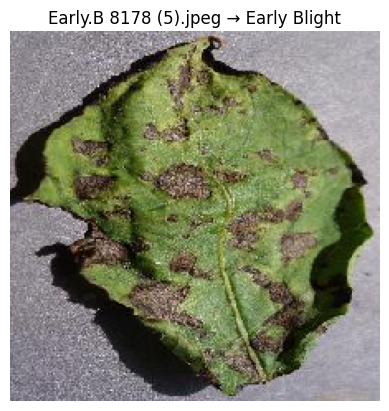

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


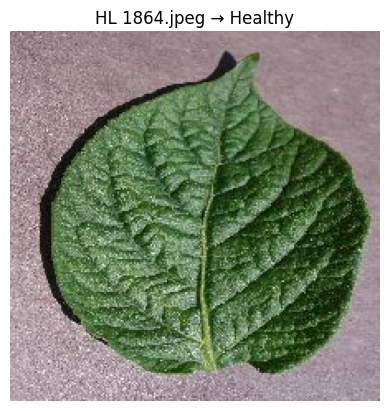

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


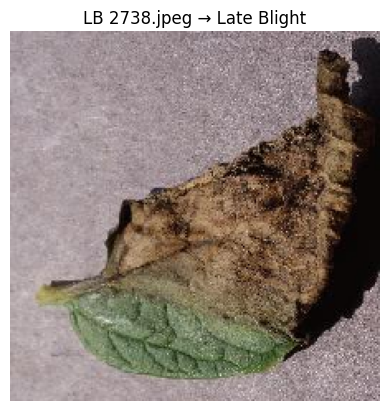

In [ ]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Upload multiple images
uploaded = files.upload()

# Class labels
class_names = ["Early Blight", "Late Blight", "Healthy"]

# Loop through all uploaded images
for img_path in uploaded.keys():

    # Load & preprocess
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = cnn_model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    # Show result
    plt.imshow(img)
    plt.title(f"{img_path} → {predicted_class}")
    plt.axis("off")
    plt.show()

# **9. Model Evaluation**

**a. Accuracy**

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 320ms/step - accuracy: 0.9938 - loss: 0.0214
Test Accuracy: 0.9937888383865356


**b. Confusion Matrix**

In [ ]:
import numpy as np
predictions = cnn_model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 345ms/step


In [ ]:
y_true = test_generator.classes

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true, y_pred)

array([[62, 70,  8],
       [73, 78, 10],
       [ 6, 12,  3]])

**c. Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.44      0.44       140
           1       0.49      0.48      0.49       161
           2       0.14      0.14      0.14        21

    accuracy                           0.44       322
   macro avg       0.36      0.36      0.36       322
weighted avg       0.44      0.44      0.44       322

